# Paper figures: eddy structure and tilt
Two properties only: **rotation strength |Omega|** and **axis ratio** versus measured tilt distance in kilometres. Figure 1 separates selected depths; Figure 2 overlays the selected depths in two panels. Red = AE, blue = CE.

Curves show eddy-day medians; light shading in Figure 1 is the interquartile range (population spread, **not** a confidence interval). Figure 2 omits shading for readability. Full selection and count tables are saved separately from the figures. No tilt is recalculated.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Launch inside seacofs_eddy_tilt_analysis')
WORK=ANALYSIS/'eddy_env_tilt_controls'
for p in (ANALYSIS,WORK):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import seacofs_tilt_tools as tilt
import paper_control_tools as paper
paths=tilt.Paths()
N_BINS=8
MIN_EDDIES_PER_BIN=20
SAVE=True
RUN_ID=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_ROOT=WORK/'paper_figures'/RUN_ID
surface,_=tilt.load_tilt_tables(paths)
print('Loaded',len(surface),'eddy-days from',surface.Eddy.nunique(),'eddies')

Loaded 127426 eddy-days from 2982 eddies


## Depth and fit controls
Candidate depths resolve to existing cached levels, without interpolation. A candidate must retain at least half the shallowest-level day count and 100 eddies **in each polarity** before matching. Both properties and all eligible candidate depths then share exactly the same Eddy-Day observations.

The strongest depths are ranked by the mean of AE and CE **absolute Spearman correlations of per-eddy medians**. The two signed correlations are shown separately below. This gives each eddy and each polarity equal influence on selection. Plot curves themselves remain daily medians, matching the original analysis. Depths are selected on the same data being displayed: this is a descriptive selection, not an independent significance test. Keep the complete ranking when reporting why these depths were chosen.

Fit screens use the existing surface-processing limits as explicit, editable screens for the depth fits: Rc ≤ 300 km, |Omega| ≤ 5×10⁻⁵ s⁻¹ and axis ratio ≤ 5, with positive radius/rotation and positive-definite ellipse matrices. These are not a new validated vertical-QC standard. Counts of each exclusion reason are shown; reasons may overlap. The previous extreme radius and speed-scale diagnostics are not plotted here.

In [2]:
TARGET_DEPTHS=[0,50,100,150,200,300,500,700,850]
MAX_DEPTH_M=1000
DEPTH_TOLERANCE_M=65
MIN_EDDIES_PER_POLARITY=100
MIN_DAY_FRACTION=.5
N_SELECTED_DEPTHS=3
MIN_DEPTH_SPACING_M=75
RC_MAX_KM=300.
OMEGA_MAX=5e-5
AR_MAX=5.
# After inspecting the ranking, optionally fix the exact depths for the paper:
# SELECTED_DEPTHS={'abs_Omega':[...], 'AR':[...]}
# Use actual depth_m values from the ranking, not nominal target depths.
SELECTED_DEPTHS=None
vertical=tilt.load_vert(paths)
clean,qc_audit=paper.prepare_depths(vertical,surface,max_depth=MAX_DEPTH_M,
                                   rc_max=RC_MAX_KM,omega_max=OMEGA_MAX,ar_max=AR_MAX)
candidates=paper.candidate_depths(clean,TARGET_DEPTHS,tolerance=DEPTH_TOLERANCE_M,
                                  min_eddies=MIN_EDDIES_PER_POLARITY,min_day_fraction=MIN_DAY_FRACTION)
levels=candidates.loc[candidates.eligible,'depth_m'].tolist()
matched=paper.matched_depths(clean,levels)
ranking=paper.rank_depths(matched,min_eddies=MIN_EDDIES_PER_POLARITY)
selected=paper.select_depths(ranking,n=N_SELECTED_DEPTHS,min_spacing=MIN_DEPTH_SPACING_M,override=SELECTED_DEPTHS)
counts=matched.groupby(['Depth','Cyc'],as_index=False).agg(eddy_days=('Day','size'),eddies=('Eddy','nunique'))
print('Candidate depths and availability:')
display(candidates)
print('QC counts at candidate levels (reasons overlap):')
display(qc_audit.loc[qc_audit.Depth.isin(candidates.depth_m)])
print('Matched sample:')
display(counts)
print('All candidate-depth correlations, strongest first within each property:')
with pd.option_context('display.max_rows',None,'display.max_columns',None): display(ranking)
print('Selected actual depths:',selected)

Candidate depths and availability:


,target_m,depth_m,mismatch_m,AE_eddy_days,AE_eddies,AE_day_fraction,CE_eddy_days,CE_eddies,CE_day_fraction,eligible
0,0,0.000000,0.000000,51167,1416,1.000000,50489,1530,1.000000,True
1,50,48.897638,1.102362,50587,1416,0.988665,49544,1530,0.981283,True
2,100,105.615538,5.615538,50674,1416,0.990365,49699,1530,0.984353,True
3,150,151.065954,1.065954,50662,1416,0.990130,49759,1530,0.985541,True
4,200,181.264793,18.735207,50601,1415,0.988938,49742,1530,0.985205,True
5,300,327.440851,27.440851,48069,1387,0.939453,48445,1520,0.959516,True
6,500,515.416489,15.416489,44273,1345,0.865265,46094,1491,0.912951,True
7,700,660.806374,39.193626,42069,1317,0.822190,44161,1480,0.874666,True
8,850,858.918478,8.918478,39552,1286,0.772998,41509,1461,0.822139,True


QC counts at candidate levels (reasons overlap):


,Depth,Cyc,rows,eddies,kept,bad_ellipse,bad_radius,bad_rotation
0,0.000000,AE,51167,1416,51167,0,0,0
1,0.000000,CE,50489,1530,50489,0,0,0
14,48.897638,AE,51167,1416,50587,26,554,0
15,48.897638,CE,50489,1530,49544,46,883,19
22,105.615538,AE,51167,1416,50674,29,465,1
23,105.615538,CE,50489,1530,49699,38,751,2
26,151.065954,AE,51167,1416,50662,34,475,0
27,151.065954,CE,50489,1530,49759,47,690,0
28,181.264793,AE,51167,1416,50601,71,505,0
29,181.264793,CE,50489,1530,49742,59,694,0


Matched sample:


,Depth,Cyc,eddy_days,eddies
0,0.000000,AE,37756,1269
1,0.000000,CE,39075,1452
2,48.897638,AE,37756,1269
3,48.897638,CE,39075,1452
4,105.615538,AE,37756,1269
5,105.615538,CE,39075,1452
6,151.065954,AE,37756,1269
7,151.065954,CE,39075,1452
8,181.264793,AE,37756,1269
9,181.264793,CE,39075,1452


All candidate-depth correlations, strongest first within each property:


,metric,depth_m,AE_rho,AE_eddies,CE_rho,CE_eddies,mean_abs_rho
15,AR,660.806374,0.269606,1269,0.173725,1452,0.221665
17,AR,858.918478,0.250583,1269,0.173734,1452,0.212159
13,AR,515.416489,0.266203,1269,0.128803,1452,0.197503
11,AR,327.440851,0.245875,1269,0.051335,1452,0.148605
9,AR,181.264793,0.154409,1269,0.023145,1452,0.088777
1,AR,0.000000,0.142430,1269,0.032290,1452,0.087360
7,AR,151.065954,0.143885,1269,0.027408,1452,0.085646
5,AR,105.615538,0.130347,1269,0.022901,1452,0.076624
3,AR,48.897638,0.126431,1269,0.024865,1452,0.075648
12,abs_Omega,515.416489,-0.468574,1269,-0.601089,1452,0.534831


Selected actual depths: {'abs_Omega': [515.416489345845, 660.8063735862158, 858.9184781094415], 'AR': [515.416489345845, 660.8063735862158, 858.9184781094415]}


## Figure 1 — individual selected depths
Each column is one selected depth for that row's property. Both polarities use shared quantile bins, and bin boundaries are fixed across the selected depths. Bins below the distinct-eddy threshold are omitted. All candidate-depth matches remain fixed even if only three depths are displayed.

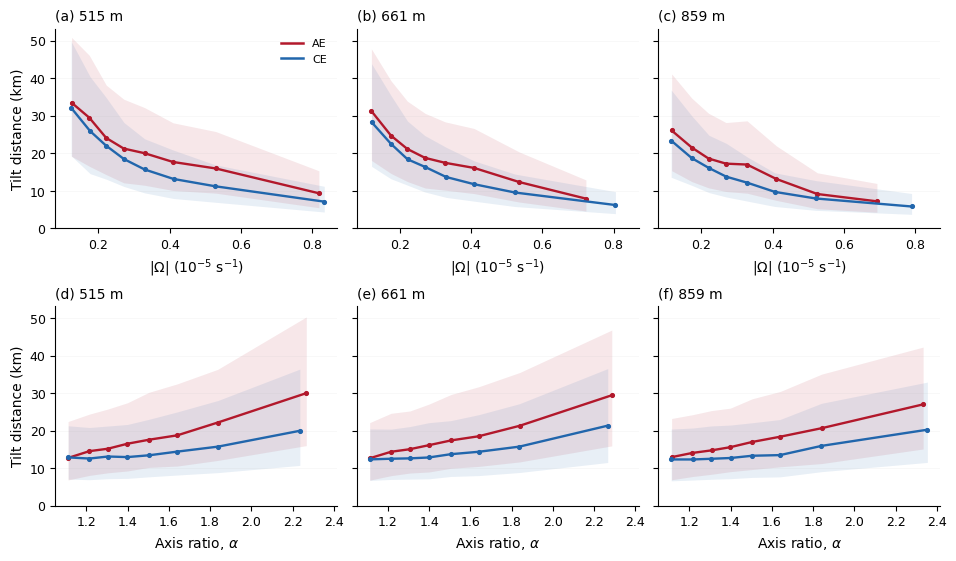

In [3]:
fig_depths,depth_bins=paper.selected_depth_figure(matched,selected,bins=N_BINS,min_eddies=MIN_EDDIES_PER_BIN)
plt.show()

## Figure 2 — strongest depth relationships together
Colour identifies polarity; line style identifies depth. Each property's legend gives its own selected depths. No overlapping bands or regression annotations.

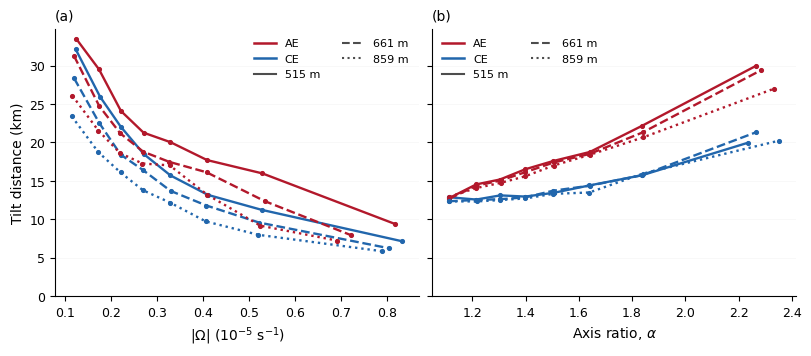

In [4]:
fig_overlay,overlay_bins=paper.overlay_figure(matched,selected,bins=N_BINS,min_eddies=MIN_EDDIES_PER_BIN)
plt.show()

## Export paper figures and supporting tables
Vector PDFs and 300-dpi PNGs are saved in a new run folder. CSVs preserve bin counts, IQRs, the complete depth ranking and exclusions. Settings and source-file metadata record the selection. Rerunning never changes the two broader analysis notebooks.

In [5]:
if SAVE:
    output=OUTPUT_ROOT/'eddy'
    paper.save_figure(fig_depths,output,'eddy_controls_selected_depths')
    paper.save_figure(fig_overlay,output,'eddy_controls_depth_overlay')
    for name,table in {'depth_candidates':candidates,'fit_qc':qc_audit,'matched_counts':counts,
                       'depth_ranking':ranking,'selected_depth_bins':depth_bins,'overlay_bins':overlay_bins}.items():
        table.to_csv(output/(name+'.csv'),index=False)
    settings=dict(target_depths=TARGET_DEPTHS,max_depth_m=MAX_DEPTH_M,depth_tolerance_m=DEPTH_TOLERANCE_M,
                  min_eddies_per_polarity=MIN_EDDIES_PER_POLARITY,min_day_fraction=MIN_DAY_FRACTION,
                  n_selected_depths=N_SELECTED_DEPTHS,min_depth_spacing_m=MIN_DEPTH_SPACING_M,
                  selected_depths=selected,rc_max_km=RC_MAX_KM,omega_max=OMEGA_MAX,ar_max=AR_MAX,
                  n_bins=N_BINS,min_eddies_per_bin=MIN_EDDIES_PER_BIN,
                  ranking='mean absolute AE/CE Spearman rho of per-eddy medians on matched days',
                  curves='eddy-day medians; IQR shading')
    paper.save_metadata(output,settings,[paths.eddies,paths.tilt,paths.vert,WORK/'paper_control_tools.py',WORK/'paper_eddy_controls.ipynb'])
    print('Paper figures and selection tables:',output)

Paper figures and selection tables: /home/z5297792/UNSW-PhD/seacofs_eddy_tilt_analysis/eddy_env_tilt_controls/paper_figures/20260925T070730113807Z/eddy
